# ReviewPulse — Exploratory Data Analysis

Multi-Domain Sentiment Dataset (Blitzer et al., 2007)  
8,000 labelled Amazon reviews across 4 domains: Books, DVDs, Electronics, Kitchen & Housewares.

**Goals:**
- Understand class and domain balance
- Inspect rating distributions
- Validate outlier removal thresholds (min/max word count)
- Audit label quality
- Inform ethics discussion for the report

In [1]:
import sys
sys.path.insert(0, '..')

import matplotlib.pyplot as plt
import pandas as pd

from src.parser import load_all_domains
from src.features import (
    class_balance,
    domain_balance,
    label_audit_summary,
    length_stats,
    plot_domain_balance,
    plot_length_distribution,
    rating_distribution,
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

## 1. Load raw data

In [2]:
df = load_all_domains()
print(f"Total reviews: {len(df):,}")
df.head(3)

Total reviews: 8,000


,text,rating,label,domain,source_file
0,Sphere by Michael Crichton is an excellant nov...,5.0,1,books,positive.review
1,Dr. Oz is an accomplished heart surgeon in the...,4.0,1,books,positive.review
2,The most gorgeous artwork in comic books. Cont...,5.0,1,books,positive.review


## 2. Class balance

A well-balanced dataset means accuracy is a reliable metric and the model won't be biased toward one class.

In [3]:
class_balance(df)

,count,pct
label,,
positive,4000,50.0
negative,4000,50.0


## 3. Domain balance

label        negative  positive
domain                         
books            1000      1000
dvd              1000      1000
electronics      1000      1000
kitchen          1000      1000
Saved → /Users/luisfaria/Desktop/sEngineer/review-pulse/notebooks/../outputs/domain_balance.png


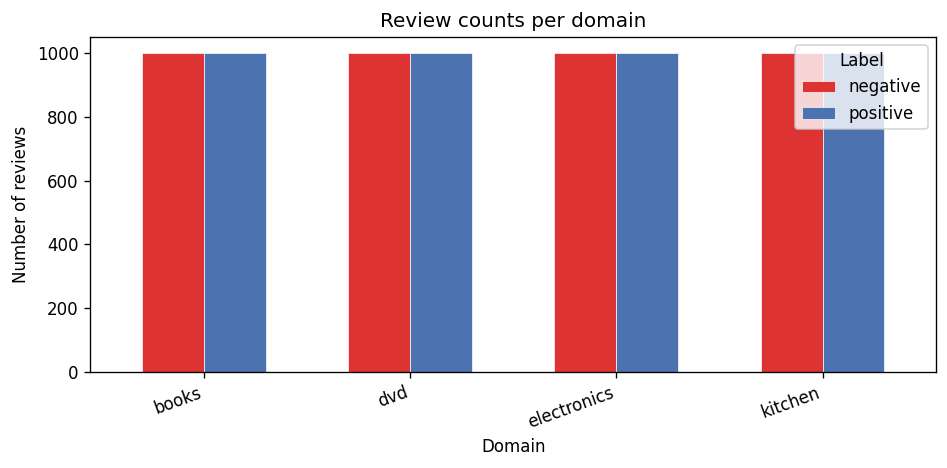

In [4]:
print(domain_balance(df))
plot_domain_balance(df)

## 4. Rating distribution

We use the **filename** as the primary label, not the star rating.  
Retaining ratings allows us to audit label quality and flag conflicts.

In [5]:
rating_distribution(df)

,count
rating,
1.0,2421
2.0,1579
4.0,1121
5.0,2879


In [6]:
# Rating distribution per label
df.groupby(['label', 'rating']).size().unstack(fill_value=0).rename(index={0: 'negative', 1: 'positive'})

rating,1.0,2.0,4.0,5.0
label,,,,
negative,2421,1579,0,0
positive,0,0,1121,2879


## 5. Review length distribution

Used to validate the outlier removal thresholds (`min_words=10`, `max_words=500`).  
Adjust these values if the distribution warrants different cutoffs.

In [7]:
length_stats(df)

,word_count
count,8000.0
mean,135.3
std,150.9
min,1.0
5%,20.0
25%,49.0
50%,90.0
75%,162.0
95%,417.0
max,3393.0


Saved → /Users/luisfaria/Desktop/sEngineer/review-pulse/notebooks/../outputs/length_distribution.png


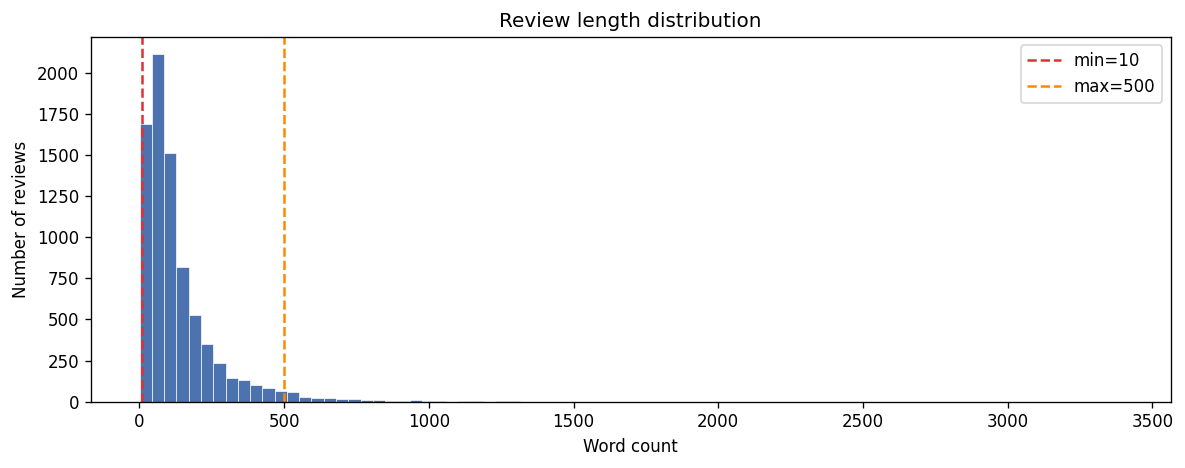

In [8]:
plot_length_distribution(df, min_words=10, max_words=500)

In [9]:
# How many reviews fall outside the thresholds?
wc = df['text'].str.split().str.len()
n_short = (wc < 10).sum()
n_long  = (wc > 500).sum()
print(f"Too short (< 10 words):  {n_short} ({n_short/len(df)*100:.1f}%)")
print(f"Too long  (> 500 words): {n_long}  ({n_long/len(df)*100:.1f}%)")
print(f"Retained after removal:  {len(df) - n_short - n_long}")

Too short (< 10 words):  20 (0.2%)
Too long  (> 500 words): 245  (3.1%)
Retained after removal:  7735


## 6. Label audit

Check for ambiguous (3-star) reviews and rating/filename conflicts.

In [10]:
label_audit_summary(df)

,count
total_reviews,8000
ambiguous_3star,0
rating_conflicts,0
clean_reviews,8000


## 7. Sample reviews

Spot-check both classes to get a feel for the language.

In [11]:
print("=== Positive sample ===")
print(df[df['label'] == 1]['text'].iloc[0][:500])
print("\n=== Negative sample ===")
print(df[df['label'] == 0]['text'].iloc[0][:500])

=== Positive sample ===
Sphere by Michael Crichton is an excellant novel. This was certainly the hardest to put down of all of the Crichton novels that I have read. 

The story revolves around a man named Norman Johnson. Johnson is a phycologist. He travels with 4 other civilans to a remote location in the Pacific Ocean to help the Navy in a top secret misssion. They quickly learn that under the ocean is a half mile long spaceship. The civilans travel to a center 1000 feet under the ocean to live while researching the 

=== Negative sample ===
THis book was horrible.  If it was possible to rate it lower than one star i would have.  I am an avid reader and picked this book up after my mom had gotten it from a friend.  I read half of it, suffering from a headache the entire time, and then got to the part about the relationship the 13 year old boy had with a 33 year old man and i lit this book on fire.  One less copy in the world...don't waste your money.

I wish i had the time spent read

## 8. Conclusions

| Finding | Implication |
|---|---|
| Dataset is perfectly balanced (50/50) | Accuracy is a reliable metric; no class weighting needed |
| 1,000 reviews per domain per class | No domain dominates training |
| 0 ambiguous (3-star) reviews | Dataset owners already excluded neutral reviews |
| 0 rating/filename conflicts | Label quality is high |
| Most reviews are 50–300 words | Thresholds min=10, max=500 are appropriate |
| ~3.5% of reviews are outliers | Small enough to drop without significant data loss |

**Ethics note:** The dataset covers only four Amazon product domains. The trained model may not generalise to other sentiment contexts (social media, healthcare, finance). Binary positive/negative classification also cannot capture neutral, mixed, or sarcastic sentiment — a limitation to be documented in the report.